## Ajuste de parâmetros inicias

A equação (18) do paper de [Labrador-Páez](https://doi.org/10.1021/acs.jpclett.3c00269?urlappend=%3Fref%3DPDF&jav=VoR&rel=cite-as) para o atraso na fase global é 
\begin{equation} \notag
\Phi (\omega) = \arctan \left( \frac{\omega}{k_{31}} \right) + \arctan \left( \frac{\omega}{k'_{5}} \right) + \arctan \left( \frac{r (\omega / k'_{21}) }{1 + r + (\omega/k'_{21})^2} \right),
\end{equation}
onde 
\begin{equation}
\begin{aligned}
& r = \frac{k_{21}}{k'_{21}} =\frac{k_{21}}{k_{21}+(\sigma P n_4/k'_5)W_{52}} \\
& k'_5 = k_{54}+W_{51}n_1
\end{aligned}
\end{equation}
Portanto, de posse dos dados experimentais é possível fazer um ajuste para estimar $k_{31}$, $k'_{5}$, $k'_{21}$ e $r$.

Ajustando 
\begin{equation}
    \Phi (\omega) = \arctan\left(\frac{\omega}{k_{31}}\right) + \arctan\left(\frac{\omega}{k_{54} + q_1}\right) + \arctan\left[ \frac{k_{21}\omega}{\left(k_{21} + \frac{q_2}{k_{54} + q_1}\right)\left(2k_{21} + \frac{q_2}{k_{54} + q_1}\right) + \omega^2} \right]
\end{equation}
onde 
$$
q_1 = W_{51}n_1, \quad q_2 = \sigma P W_{52}n_4
$$


### Ajuste e mais

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

pd = np.array([
       [ 1.00000000e+00, -2.78640057e-03,  3.36729982e-03],
       [ 2.00000000e+00, -2.94542499e-03,  3.30445647e-03],
       [ 3.00000000e+00, -5.70062310e-03,  2.22292791e-03],
       [ 5.00000000e+00, -1.15347657e-03,  3.38780739e-03],
       [ 7.00000000e+00, -1.14123889e-02,  3.33181254e-03],
       [ 1.00000000e+01, -7.57860157e-03,  3.31657015e-03],
       [ 2.00000000e+01, -1.25420350e-02,  3.19388745e-03],
       [ 3.00000000e+01, -1.16159364e-02,  3.66126559e-03],
       [ 5.00000000e+01, -2.39443326e-02,  3.09906367e-03],
       [ 7.00000000e+01, -3.15226287e-02,  2.85755006e-03],
       [ 1.00000000e+02, -5.28665836e-02,  3.35273380e-03],
       [ 2.00000000e+02, -8.30688285e-02,  2.73059639e-03],
       [ 3.00000000e+02, -1.33267253e-01,  4.03296653e-03],
       [ 5.00000000e+02, -2.24394939e-01,  3.47703795e-03],
       [ 7.00000000e+02, -3.65668758e-01,  3.51463917e-03],
       [ 1.00000000e+03, -4.71239925e-01,  3.47630975e-03],
       [ 2.00000000e+03, -6.40636375e-01,  3.75070348e-03],
       [ 3.00000000e+03, -8.06144725e-01,  3.44250145e-03],
       [ 5.00000000e+03, -9.67168365e-01,  2.84889823e-03],
       [ 7.00000000e+03, -1.18290875e+00,  3.72268580e-03],
       [ 1.00000000e+04, -1.34746600e+00,  4.92232407e-03],
       [ 2.00000000e+04, -1.40335577e+00,  8.13990120e-03],
       [ 3.00000000e+04, -1.48759587e+00,  1.57209815e-02],
       [ 5.00000000e+04, -1.34833651e+00,  2.13302156e-02],
       [ 7.00000000e+04, -1.28640332e+00,  3.61040996e-02],
       [ 1.00000000e+05, -1.23208184e+00,  6.92253145e-02]
])

frequencias = pd[:, 0]
fases_exp = np.abs(pd[:, 1]) 
erros_exp = pd[:, 2]

In [130]:
# Estimativa de n1 e n4
dens_y2o3 = 5.010 #g/cm^3
massa_molar_y2o3 = 225.81 #g/mol
frac_er = 0.005 # percentual de Er3+ da amostra
frac_yb = 0.015 # percentual de Yb3+ da amostra

n1 = (dens_y2o3/massa_molar_y2o3)*(6.022e23)*2*(frac_er)
n4 = (dens_y2o3/massa_molar_y2o3)*(6.022e23)*2*(frac_yb)
print(n1, n4)

1.33608874717683e+20 4.00826624153049e+20


In [131]:
ww51 = 1e-17
ww52 = 1e-17

sigma = 1.75e-20 
P = 5.4e20 

print(f"q1 = {ww51*n1}")
print(f"q2 = {sigma*P*ww52*n4}")

q1 = 1336.08874717683
q2 = 37878.115982463125


In [132]:
# chutes = np.array([10**i for i in range(3)])*(1e-6)
chutes = [1336.08874717683, 37878.115982463125, 192.0 ]

chutes 

### Variando $k_{31}$

Realizando ajuste de curva para q1 e q2 desacoplados


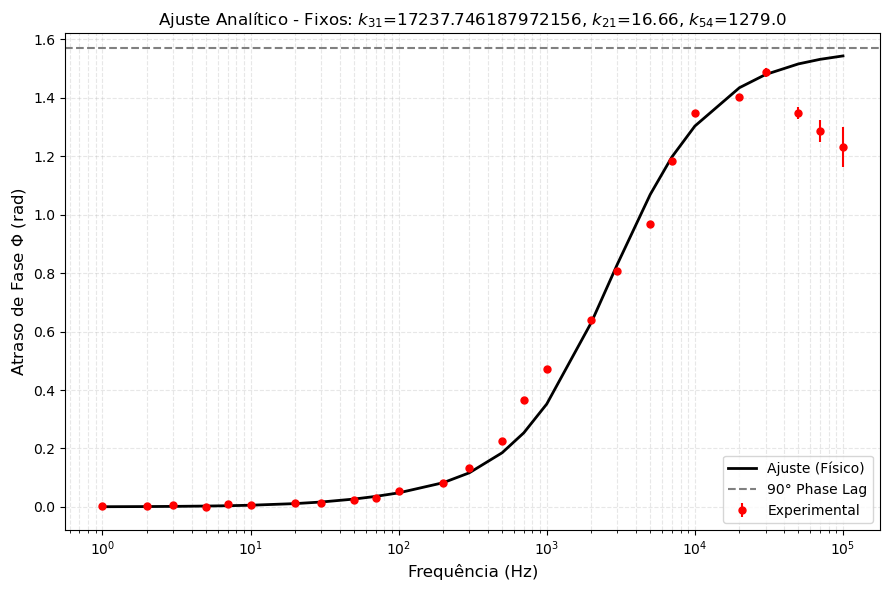

In [133]:
# ---------------------------------------------------------
# 1. CONSTANTES DA LITERATURA
# ---------------------------------------------------------
#k31_fixo = 192.0  # Substitua pelo valor correto 
k21_fixo = 16.66   # Substitua pelo valor correto 
k54_fixo = 1279.0  # Substitua pelo valor correto 

# ---------------------------------------------------------
# 3. FUNÇÃO ANALÍTICA (FORMA ELEGANTE FATORADA)
# ---------------------------------------------------------
def equacao_18_fisica(f, q1, q2, k31_fixo):
    w = 2 * np.pi * f
    
    # Fração comum que se repete no denominador do 3º termo
    termo_q = q2 / (k54_fixo + q1)
    
    # Primeiros dois termos
    termo1 = np.arctan(w / k31_fixo)
    termo2 = np.arctan(w / (k54_fixo + q1))
    
    # Terceiro termo fiel à fatoração matemática
    numerador3 = k21_fixo * w
    denominador3 = (k21_fixo + termo_q) * (2 * k21_fixo + termo_q) + w**2
    termo3 = np.arctan(numerador3 / denominador3)
    
    return termo1 + termo2 + termo3

# ---------------------------------------------------------
# 4. OTIMIZAÇÃO (CURVE FIT)
# ---------------------------------------------------------
limites_inferiores = [0.0, 0.0, 0.0]
limites_superiores = [np.inf, np.inf, np.inf]

chute_inicial = [1336.08874717683, 37878.115982463125, 192.0] ## q1, q2, k_31

print(f"Realizando ajuste de curva para q1 e q2 desacoplados")
parametros_otimizados, matriz_covariancia = curve_fit(
    equacao_18_fisica, 
    frequencias, 
    fases_exp, 
    p0=chute_inicial,
    bounds=(limites_inferiores, limites_superiores),
    sigma=erros_exp,
    absolute_sigma=True,
    maxfev=20000, 
    method='trf'
)
q1_fit, q2_fit, k31_fit = parametros_otimizados
# Reconstruindo as taxas com os parâmetros ajustados
# k5_linha_efetivo = k54_fixo + q1_fit
# k21_linha_efetivo = k21_fit + (q2_fit / k5_linha_efetivo)
# r_efetivo = k21_fit / k21_linha_efetivo
# print("-" * 50)
# print("PARÂMETROS DE AJUSTE:")
# print(f"q_1 = {q1_fit:.2f} s⁻¹")
# print(f"q_2 = {q2_fit:.2e} s⁻²")  # Em notação científica devido ao tamanho
# print("-" * 50)
# print("TAXAS EFETIVAS RECONSTRUÍDAS:")
# print(f"k'_5  = {k5_linha_efetivo:.2f} s⁻¹")
# print(f"k'_21 = {k21_linha_efetivo:.2f} s⁻¹")
# print(f"r     = {r_efetivo:.4f}")
# print("-" * 50)
# ---------------------------------------------------------
# 5. PLOTAGEM DOS RESULTADOS
# ---------------------------------------------------------
fases_ajustadas = equacao_18_fisica(frequencias, *parametros_otimizados)
plt.figure(figsize=(9, 6))
plt.errorbar(frequencias, fases_exp, yerr=erros_exp, fmt='o', color='red', label='Experimental', markersize=5)
plt.plot(frequencias, fases_ajustadas, color='black', linewidth=2, label='Ajuste (Físico)')
plt.axhline(np.pi/2, color='gray', linestyle='--', label='90° Phase Lag')
plt.xscale('log')
plt.xlabel('Frequência (Hz)', fontsize=12)
plt.ylabel('Atraso de Fase $\Phi$ (rad)', fontsize=12)
plt.title(f'Ajuste Analítico - Fixos: $k_{{31}}$={k31_fit}, $k_{{21}}$={k21_fixo}, $k_{{54}}$={k54_fixo}', fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [134]:
print(f"W51 = {q1_fit/n1}")
print(f"W52 = {q2_fit/(sigma*P*n4)}")

W51 = 8.192933479247868e-09
W52 = 1.9970817793515877e-07


### Variando $k_{21}$

Realizando ajuste de curva para q1 e q2 desacoplados


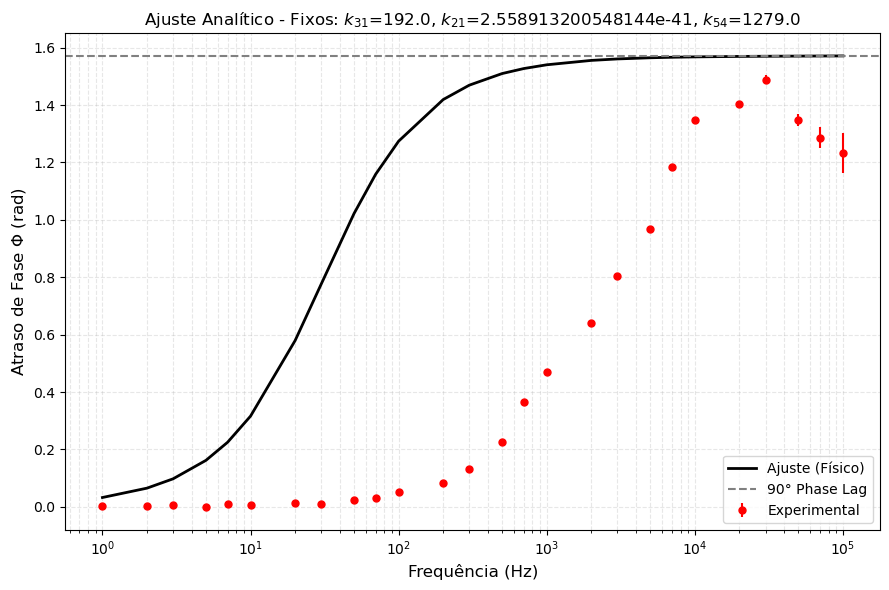

In [135]:
# ---------------------------------------------------------
# 1. CONSTANTES DA LITERATURA
# ---------------------------------------------------------
k31_fixo = 192.0  # Substitua pelo valor correto 
# k21_fixo = 16.66   # Substitua pelo valor correto 
k54_fixo = 1279.0  # Substitua pelo valor correto 



# ---------------------------------------------------------
# 3. FUNÇÃO ANALÍTICA (FORMA ELEGANTE FATORADA)
# ---------------------------------------------------------
def equacao_18_fisica(f, q1, q2, k21_fixo):
    w = 2 * np.pi * f
    
    # Fração comum que se repete no denominador do 3º termo
    termo_q = q2 / (k54_fixo + q1)
    
    # Primeiros dois termos
    termo1 = np.arctan(w / k31_fixo)
    termo2 = np.arctan(w / (k54_fixo + q1))
    
    # Terceiro termo fiel à fatoração matemática
    numerador3 = k21_fixo * w
    denominador3 = (k21_fixo + termo_q) * (2 * k21_fixo + termo_q) + w**2
    termo3 = np.arctan(numerador3 / denominador3)
    
    return termo1 + termo2 + termo3

# ---------------------------------------------------------
# 4. OTIMIZAÇÃO (CURVE FIT)
# ---------------------------------------------------------
limites_inferiores = [0.0, 0.0, 0.0]
limites_superiores = [np.inf, np.inf, np.inf]



chute_inicial = [1336.08874717683, 37878.115982463125, 16.0]

print(f"Realizando ajuste de curva para q1 e q2 desacoplados")
parametros_otimizados, matriz_covariancia = curve_fit(
    equacao_18_fisica, 
    frequencias, 
    fases_exp, 
    p0=chute_inicial,
    bounds=(limites_inferiores, limites_superiores),
    sigma=erros_exp,
    absolute_sigma=True,
    maxfev=20000, 
    method='trf'
)

q1_fit, q2_fit, k21_fit = parametros_otimizados

# Reconstruindo as taxas com os parâmetros ajustados
# k5_linha_efetivo = k54_fixo + q1_fit
# k21_linha_efetivo = k21_fit + (q2_fit / k5_linha_efetivo)
# r_efetivo = k21_fit / k21_linha_efetivo
# print("-" * 50)
# print("PARÂMETROS DE AJUSTE:")
# print(f"q_1 = {q1_fit:.2f} s⁻¹")
# print(f"q_2 = {q2_fit:.2e} s⁻²")  # Em notação científica devido ao tamanho
# print("-" * 50)
# print("TAXAS EFETIVAS RECONSTRUÍDAS:")
# print(f"k'_5  = {k5_linha_efetivo:.2f} s⁻¹")
# print(f"k'_21 = {k21_linha_efetivo:.2f} s⁻¹")
# print(f"r     = {r_efetivo:.4f}")
# print("-" * 50)
# ---------------------------------------------------------
# 5. PLOTAGEM DOS RESULTADOS
# ---------------------------------------------------------
fases_ajustadas = equacao_18_fisica(frequencias, *parametros_otimizados)
plt.figure(figsize=(9, 6))
plt.errorbar(frequencias, fases_exp, yerr=erros_exp, fmt='o', color='red', label='Experimental', markersize=5)
plt.plot(frequencias, fases_ajustadas, color='black', linewidth=2, label='Ajuste (Físico)')
plt.axhline(np.pi/2, color='gray', linestyle='--', label='90° Phase Lag')
plt.xscale('log')
plt.xlabel('Frequência (Hz)', fontsize=12)
plt.ylabel('Atraso de Fase $\Phi$ (rad)', fontsize=12)
plt.title(f'Ajuste Analítico - Fixos: $k_{{31}}$={k31_fixo}, $k_{{21}}$={k21_fit}, $k_{{54}}$={k54_fixo}', fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [136]:
print(f"W51 = {q1_fit/n1}")
print(f"W52 = {q2_fit/(sigma*P*n4)}")

W51 = 6.980477117739257e-12
W52 = 1.941873984026367e-17


### Variando $k_{54}$

Realizando ajuste de curva para q1 e q2 desacoplados


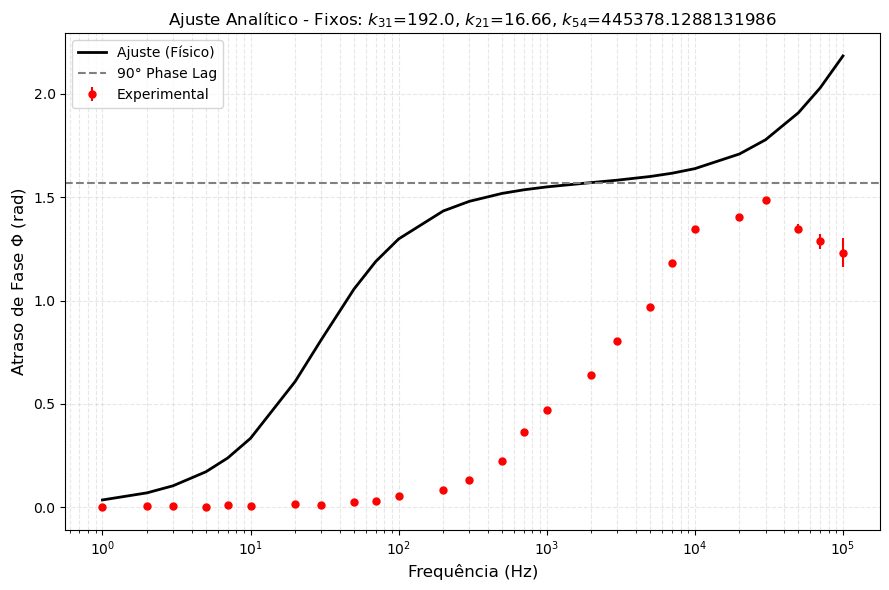

In [137]:
# ---------------------------------------------------------
# 1. CONSTANTES DA LITERATURA
# ---------------------------------------------------------
k31_fixo = 192.0  # Substitua pelo valor correto 
k21_fixo = 16.66   # Substitua pelo valor correto 
# k54_fixo = 1279.0  # Substitua pelo valor correto 



# ---------------------------------------------------------
# 3. FUNÇÃO ANALÍTICA (FORMA ELEGANTE FATORADA)
# ---------------------------------------------------------
def equacao_18_fisica(f, q1, q2, k54_fixo):
    w = 2 * np.pi * f
    
    # Fração comum que se repete no denominador do 3º termo
    termo_q = q2 / (k54_fixo + q1)
    
    # Primeiros dois termos
    termo1 = np.arctan(w / k31_fixo)
    termo2 = np.arctan(w / (k54_fixo + q1))
    
    # Terceiro termo fiel à fatoração matemática
    numerador3 = k21_fixo * w
    denominador3 = (k21_fixo + termo_q) * (2 * k21_fixo + termo_q) + w**2
    termo3 = np.arctan(numerador3 / denominador3)
    
    return termo1 + termo2 + termo3

# ---------------------------------------------------------
# 4. OTIMIZAÇÃO (CURVE FIT)
# ---------------------------------------------------------
limites_inferiores = [0.0, 0.0, 0.0]
limites_superiores = [np.inf, np.inf, np.inf]



chute_inicial = [1336.08874717683, 37878.115982463125, 1279.0]

print(f"Realizando ajuste de curva para q1 e q2 desacoplados")
parametros_otimizados, matriz_covariancia = curve_fit(
    equacao_18_fisica, 
    frequencias, 
    fases_exp, 
    p0=chute_inicial,
    bounds=(limites_inferiores, limites_superiores),
    sigma=erros_exp,
    absolute_sigma=True,
    maxfev=20000, 
    method='trf'
)

q1_fit, q2_fit, k54_fit = parametros_otimizados

# Reconstruindo as taxas com os parâmetros ajustados
# k5_linha_efetivo = k54_fixo + q1_fit
# k21_linha_efetivo = k21_fit + (q2_fit / k5_linha_efetivo)
# r_efetivo = k21_fit / k21_linha_efetivo
# print("-" * 50)
# print("PARÂMETROS DE AJUSTE:")
# print(f"q_1 = {q1_fit:.2f} s⁻¹")
# print(f"q_2 = {q2_fit:.2e} s⁻²")  # Em notação científica devido ao tamanho
# print("-" * 50)
# print("TAXAS EFETIVAS RECONSTRUÍDAS:")
# print(f"k'_5  = {k5_linha_efetivo:.2f} s⁻¹")
# print(f"k'_21 = {k21_linha_efetivo:.2f} s⁻¹")
# print(f"r     = {r_efetivo:.4f}")
# print("-" * 50)
# ---------------------------------------------------------
# 5. PLOTAGEM DOS RESULTADOS
# ---------------------------------------------------------
fases_ajustadas = equacao_18_fisica(frequencias, *parametros_otimizados)
plt.figure(figsize=(9, 6))
plt.errorbar(frequencias, fases_exp, yerr=erros_exp, fmt='o', color='red', label='Experimental', markersize=5)
plt.plot(frequencias, fases_ajustadas, color='black', linewidth=2, label='Ajuste (Físico)')
plt.axhline(np.pi/2, color='gray', linestyle='--', label='90° Phase Lag')
plt.xscale('log')
plt.xlabel('Frequência (Hz)', fontsize=12)
plt.ylabel('Atraso de Fase $\Phi$ (rad)', fontsize=12)
plt.title(f'Ajuste Analítico - Fixos: $k_{{31}}$={k31_fixo}, $k_{{21}}$={k21_fixo}, $k_{{54}}$={k54_fit}', fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [138]:
print(f"W51 = {q1_fit/n1}")
print(f"W52 = {q2_fit/(sigma*P*n4)}")

W51 = 3.344515931228883e-15
W52 = 5.138966295595258e-14


## Junk

In [139]:
import sympy as sp****
from IPython.display import display # Importante para mostrar o LaTeX no VSCode

# Ativa a renderização bonita (LaTeX/MathJax)
sp.init_printing()

# 1. Definindo as variáveis simbólicas
W51, W52 = sp.symbols('W_51 W_52')
k21, k21_prime, k5_prime, k45_prime, k54 = sp.symbols("k_21 k'_21 k'_5 k'_45 k_54")
sigma, P, n1, n4, r = sp.symbols('sigma P n_1 n_4 r')

# 2. Escrevendo as equações a partir das imagens
eq_k5_prime = sp.Eq(k5_prime, k54 + W51 * n1)
eq_k45_prime = sp.Eq(k45_prime, sigma * P * n4)
eq_k21_prime = sp.Eq(k21_prime, k21 + (k45_prime / k5_prime) * W52)

# 3. Resolvendo o sistema para W51
solucao_W51 = sp.solve(eq_k5_prime, W51)[0]

# 4. Resolvendo o sistema para W52
solucao_W52_parcial = sp.solve(eq_k21_prime, W52)[0]
solucao_W52_final = solucao_W52_parcial.subs(k45_prime, sigma * P * n4)

# 5. Exibindo os resultados em LaTeX
# Criamos equações formais (Eq) só para a exibição ficar perfeita:
display(sp.Eq(W51, solucao_W51))
display(sp.Eq(W52, solucao_W52_final))

SyntaxError: invalid syntax (1905239257.py, line 1)

In [ ]:
#--------------------------------------
# Parâmetros inseridos
#--------------------------------------
sigma = 1.75e-20 # cm^2
P = 5.4e20  # fótons / (cm^2 * s) (baseado em 110 W/cm^2)
n1 = 2.3e20 # Supporting Information, page S5, Labrador
n4 = 1.3e21 # Supporting Information, page S5, Labrador
k54 = 1279.0 #

#--------------------------------------
#Ajustado via eq. (18)
#--------------------------------------
k31  = 24133.48
kp5  = 193625318602.30
kp21 = 7063.64
r     = 0.4620

print(50*"=")
print("Taxas de decaimentos radiativos:")
print(f"k21 = {(r*kp21):.5}")
print(f"k31 = {(k31):.5}")
print(50*"=")
print("Taxas de decaimentos não radiativos:")
print(f"W51 = {((kp5-k54)/n1):.5}")
print(f"W52 = {(kp5*kp21*(1-r)/(sigma*P*n4)):.5}")
print(50*"=")